# 05 — Bowling Analysis

**Goal**: Build comprehensive bowler profiles and analyse matchup effectiveness.

**Input**: `data/final_processed_data.csv`

**Outputs**:
- `data/bowler_stats.csv` — per-bowler aggregate stats
- `data/bowling_success_model.csv` — per bowler-vs-batsman matchup stats

**Metrics**:
- Economy rate, strike rate, dot ball %, wicket %, boundary %
- Composite success index = 30% economy + 30% dot balls + 40% wickets
- Strength zone: Elite / Strong / Average / Weak
- Phase-wise bowling stats
- Bowler-vs-batsman matchup analysis

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_OUT     = os.path.join(PROJECT_ROOT, 'data')

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 110})

## 1. Load Data

In [15]:
df = pd.read_csv(os.path.join(DATA_OUT, 'final_processed_data.csv'))

for col in ['isFour','isSix','isWicket']:
    df[col] = df[col].astype(int)
df['isBoundary'] = ((df['isFour']==1)|(df['isSix']==1)).astype(int)
df['isDotBall']  = (df['run'] == 0).astype(int)

def get_phase(o):
    if o <= 6:  return 'Powerplay'
    if o <= 15: return 'Middle'
    return 'Death'
df['match_phase'] = df['oversActual'].apply(get_phase)

print(f'Loaded {len(df):,} deliveries | {df["Bowler_Name"].nunique()} bowlers')

Loaded 33,029 deliveries | 318 bowlers


## 2. Core Bowler Statistics

In [16]:
bowler_stats = df.groupby(['Bowler_Name', 'Bowler_Bowling_Style']).agg(
    balls_bowled     = ('run', 'count'),
    total_runs       = ('run', 'sum'),
    total_boundaries = ('isBoundary', 'sum'),
    total_wickets    = ('isWicket', 'sum'),
    dot_balls        = ('isDotBall', 'sum')
).reset_index()

# Derived metrics
bs = bowler_stats
bs['economy_rate']       = (bs['total_runs'] / (bs['balls_bowled'] / 6)).round(3)
bs['bowling_sr']         = np.where(bs['total_wickets'] > 0,
                                     (bs['balls_bowled'] / bs['total_wickets']).round(2), np.nan)
bs['boundary_pct']       = (bs['total_boundaries'] / bs['balls_bowled'] * 100).round(2)
bs['dot_ball_pct']       = (bs['dot_balls']         / bs['balls_bowled'] * 100).round(2)
bs['wicket_pct']         = (bs['total_wickets']     / bs['balls_bowled'] * 100).round(2)

bs.replace([np.inf, -np.inf], np.nan, inplace=True)

# ── Success Index ────────────────────────────────────────────────────────────
# Economy: normalise so lower is better (invert); use 0-12 scale
# Dot ball %: higher is better
# Wicket %: higher is better
bs['economy_score']   = ((12 - bs['economy_rate'].clip(0, 12)) / 12 * 100).fillna(0)
bs['success_index']   = (
    bs['economy_score'] * 0.30 +
    bs['dot_ball_pct']  * 0.30 +
    bs['wicket_pct']    * 0.40
).round(3)

# Normalise success index to 0-1
scaler = MinMaxScaler()
bs['success_index_scaled'] = scaler.fit_transform(bs[['success_index']]).ravel().round(4)

# Strength zone
def strength_zone(s):
    if s >= 0.75: return 'Elite'
    if s >= 0.50: return 'Strong'
    if s >= 0.25: return 'Average'
    return 'Weak'
bs['bowler_strength_zone'] = bs['success_index_scaled'].apply(strength_zone)

bs.sort_values('success_index_scaled', ascending=False, inplace=True)
bs.reset_index(drop=True, inplace=True)

print('Strength zone distribution:')
print(bs['bowler_strength_zone'].value_counts())
bs.head(10)

Strength zone distribution:
bowler_strength_zone
Strong     169
Average     85
Elite       38
Weak        26
Name: count, dtype: int64


,Bowler_Name,Bowler_Bowling_Style,balls_bowled,total_runs,total_boundaries,total_wickets,dot_balls,economy_rate,bowling_sr,boundary_pct,dot_ball_pct,wicket_pct,economy_score,success_index,success_index_scaled,bowler_strength_zone
0,DS Airee,"right-arm medium,right-arm offbreak",12,6,0,1,7,3.000,12.00,0.00,58.33,8.33,75.000000,43.331,1.0000,Elite
1,OEG Baartman,right-arm medium-fast,74,48,5,5,47,3.892,14.80,6.76,63.51,6.76,67.566667,42.027,0.9699,Elite
2,NL McCullum,right-arm offbreak,31,21,1,3,16,4.065,10.33,3.23,51.61,9.68,66.125000,39.192,0.9045,Elite
3,BJ Currie,left-arm fast-medium,24,16,1,2,12,4.000,12.00,4.17,50.00,8.33,66.666667,38.332,0.8846,Elite
4,M Jansen,left-arm medium-fast,72,53,5,3,42,4.417,24.00,6.94,58.33,4.17,63.191667,38.124,0.8798,Elite
5,KS Williamson,right-arm offbreak,6,3,0,0,3,3.000,NaN,0.00,50.00,0.00,75.000000,37.500,0.8654,Elite
6,Sompal Kami,right-arm fast-medium,24,18,2,2,12,4.500,12.00,8.33,50.00,8.33,62.500000,37.082,0.8558,Elite
7,A Nortje,right-arm fast,300,258,23,33,154,5.160,9.09,7.67,51.33,11.00,57.000000,36.899,0.8516,Elite
8,Fazalhaq Farooqi,left-arm fast-medium,132,122,14,11,73,5.545,12.00,10.61,55.30,8.33,53.791667,36.060,0.8322,Elite
9,VJ Kingma,right-arm medium-fast,64,57,7,3,37,5.344,21.33,10.94,57.81,4.69,55.466667,35.859,0.8276,Elite


## 3. Phase-wise Bowling Stats

In [17]:
phase_bowling = df.groupby(['Bowler_Name', 'match_phase']).agg(
    balls    = ('run', 'count'),
    runs     = ('run', 'sum'),
    wickets  = ('isWicket', 'sum'),
    dot_balls= ('isDotBall', 'sum')
).reset_index()

phase_bowling['economy']  = (phase_bowling['runs'] / (phase_bowling['balls'] / 6)).round(2)
phase_bowling['dot_pct']  = (phase_bowling['dot_balls'] / phase_bowling['balls'] * 100).round(1)
phase_bowling['wkt_pct']  = (phase_bowling['wickets']   / phase_bowling['balls'] * 100).round(2)

# Pivot to attach phase columns to bowler_stats
econ_pivot = phase_bowling.pivot_table('economy', index='Bowler_Name', columns='match_phase').fillna(0)
econ_pivot.columns = ['econ_' + c.lower() for c in econ_pivot.columns]

bs = bs.merge(econ_pivot, on='Bowler_Name', how='left')
print('Phase economy columns added:', [c for c in bs.columns if c.startswith('econ_')])

Phase economy columns added: ['econ_death', 'econ_middle', 'econ_powerplay']


## 4. Save Bowler Stats

In [18]:
# Drop intermediate economy_score column before saving
bs_save = bs.drop(columns=['economy_score'], errors='ignore')
out_path = os.path.join(DATA_OUT, 'bowler_stats.csv')
bs_save.to_csv(out_path, index=False)
print(f'Saved → {out_path}  ({len(bs_save)} bowlers × {len(bs_save.columns)} columns)')

Saved → c:\Users\yaswa\OneDrive\Desktop\projects\artificial intelligence project\data\bowler_stats.csv  (318 bowlers × 18 columns)


## 5. Bowler vs Batsman Matchup Model

In [19]:
matchup = df.groupby(['Full Name_bowler', 'Bowler_Bowling_Style', 'Full Name']).agg(
    balls_bowled     = ('run', 'count'),
    total_runs       = ('run', 'sum'),
    total_boundaries = ('isBoundary', 'sum'),
    total_wickets    = ('isWicket', 'sum'),
    dot_balls        = ('isDotBall', 'sum')
).reset_index()

# Filter: at least 3 balls for a meaningful matchup
matchup = matchup[matchup['balls_bowled'] >= 3].copy()

matchup['economy_rate']   = (matchup['total_runs']       / (matchup['balls_bowled']/6)).round(3)
matchup['boundary_pct']   = (matchup['total_boundaries'] /  matchup['balls_bowled'] * 100).round(2)
matchup['dot_ball_pct']   = (matchup['dot_balls']        /  matchup['balls_bowled'] * 100).round(2)
matchup['wicket_pct']     = (matchup['total_wickets']    /  matchup['balls_bowled'] * 100).round(2)

matchup.replace([np.inf,-np.inf], np.nan, inplace=True)
matchup.fillna(0, inplace=True)

matchup['economy_score']  = ((12 - matchup['economy_rate'].clip(0,12)) / 12 * 100)
matchup['success_index']  = (
    matchup['economy_score'] * 0.30 +
    matchup['dot_ball_pct']  * 0.30 +
    matchup['wicket_pct']    * 0.40
).round(3)

matchup['success_index_scaled'] = scaler.fit_transform(matchup[['success_index']]).ravel().round(4)

def perf_label(x):
    if x >= 0.75: return 'High Success'
    if x >= 0.50: return 'Moderate Success'
    return 'Low Success'
matchup['performance_label'] = matchup['success_index_scaled'].apply(perf_label)

matchup.rename(columns={'Full Name_bowler': 'Bowler_Name', 'Full Name': 'Batsman_Name'}, inplace=True)
matchup.drop(columns=['economy_score'], inplace=True)
matchup.sort_values('success_index_scaled', ascending=False, inplace=True)
matchup.reset_index(drop=True, inplace=True)

print(f'Matchup records: {len(matchup):,}')
print(matchup['performance_label'].value_counts())

matchup_path = os.path.join(DATA_OUT, 'bowling_success_model.csv')
matchup.to_csv(matchup_path, index=False)
print(f'Saved → {matchup_path}')

Matchup records: 4,936
performance_label
Low Success         3661
Moderate Success     999
High Success         276
Name: count, dtype: int64
Saved → c:\Users\yaswa\OneDrive\Desktop\projects\artificial intelligence project\data\bowling_success_model.csv


## 6. Visualisations

In [20]:
# ── Strength zone distribution pie ───────────────────────────────────────────
zone_counts = bs['bowler_strength_zone'].value_counts().reset_index()
zone_counts.columns = ['zone', 'count']
fig = px.pie(zone_counts, names='zone', values='count',
             title='Bowler Strength Zone Distribution',
             color='zone',
             color_discrete_map={'Elite':'#2ecc71','Strong':'#3498db','Average':'#f39c12','Weak':'#e74c3c'},
             hole=0.35)
fig.update_traces(textinfo='percent+label')
fig.show()

In [21]:
# ── Top 15 bowlers by success index ──────────────────────────────────────────
top15 = bs[bs['balls_bowled'] >= 30].head(15)
fig = px.bar(top15, x='Bowler_Name', y='success_index_scaled',
             color='bowler_strength_zone',
             color_discrete_map={'Elite':'#2ecc71','Strong':'#3498db','Average':'#f39c12','Weak':'#e74c3c'},
             title='Top 15 Bowlers by Success Index (min 30 balls)',
             text=top15['success_index_scaled'].round(3),
             hover_data=['economy_rate','dot_ball_pct','wicket_pct'])
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_tickangle=-35, xaxis_title='', yaxis_title='Success Index (0–1)')
fig.show()

In [22]:
# ── Economy vs Wicket % scatter ───────────────────────────────────────────────
plot_bs = bs[bs['balls_bowled'] >= 30].copy()
fig = px.scatter(
    plot_bs, x='economy_rate', y='wicket_pct',
    size='dot_ball_pct', color='success_index_scaled',
    hover_name='Bowler_Name',
    color_continuous_scale='RdYlGn',
    title='Economy Rate vs Wicket % (bubble = Dot Ball %, colour = Success Index)',
    labels={'economy_rate':'Economy Rate','wicket_pct':'Wicket %'}
)
fig.show()

In [23]:
# ── Bowling style success box plot ───────────────────────────────────────────
style_bs = bs[bs['balls_bowled'] >= 20].copy()
fig = px.box(style_bs, x='Bowler_Bowling_Style', y='success_index_scaled',
             color='Bowler_Bowling_Style',
             title='Success Index Distribution by Bowling Style',
             points='outliers')
fig.update_layout(xaxis_tickangle=-40, showlegend=False, xaxis_title='', yaxis_title='Success Index')
fig.show()

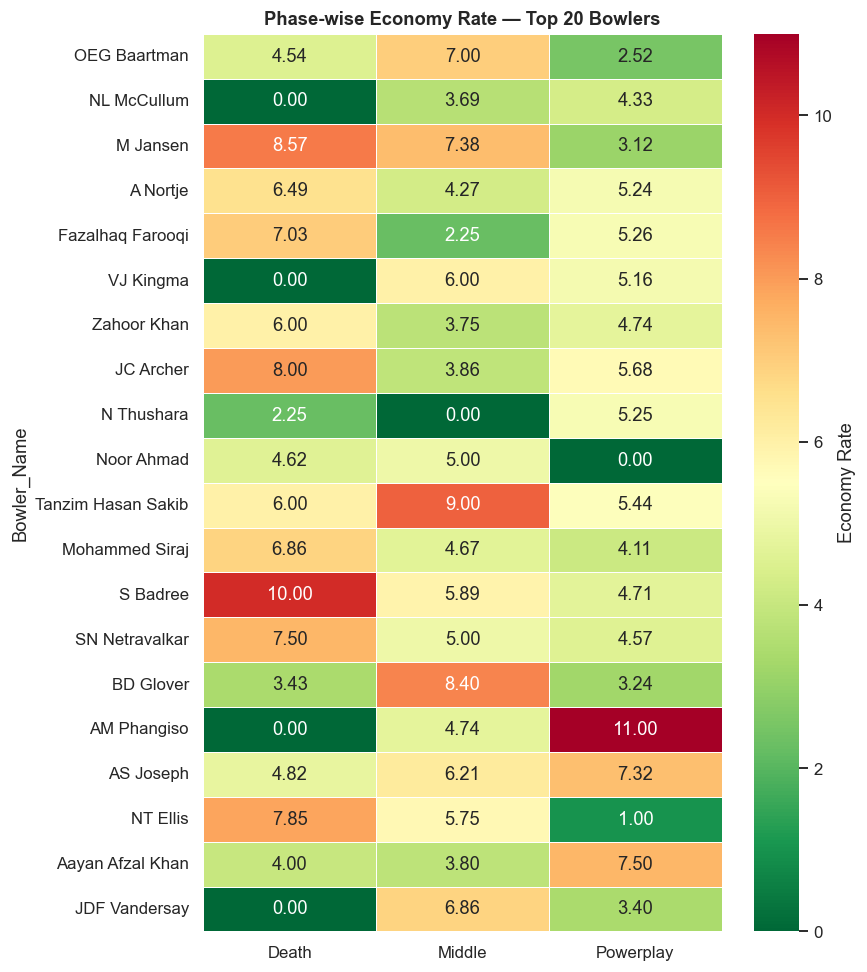

In [24]:
# ── Phase-wise economy heatmap ────────────────────────────────────────────────
phase_cols = [c for c in bs.columns if c.startswith('econ_')]
top20_names = bs[bs['balls_bowled']>=30].head(20)['Bowler_Name'].tolist()
phase_heat = bs[bs['Bowler_Name'].isin(top20_names)].set_index('Bowler_Name')[phase_cols]
phase_heat.columns = [c.replace('econ_','').capitalize() for c in phase_heat.columns]

plt.figure(figsize=(8, 9))
sns.heatmap(phase_heat, annot=True, fmt='.2f', cmap='RdYlGn_r', linewidths=0.4,
            cbar_kws={'label': 'Economy Rate'})
plt.title('Phase-wise Economy Rate — Top 20 Bowlers', fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# ── Top bowlers vs a specific batsman ────────────────────────────────────────
def show_best_bowlers_vs(batsman_query, top_n=10):
    mask   = matchup['Batsman_Name'].str.lower().str.contains(batsman_query.lower(), na=False)
    subset = matchup[mask].head(top_n)
    if subset.empty:
        print(f'No matchup data for "{batsman_query}"')
        return
    fig = px.bar(
        subset, x='Bowler_Name', y='success_index_scaled',
        color='Bowler_Bowling_Style',
        hover_data=['economy_rate','wicket_pct','dot_ball_pct'],
        title=f'Most Effective Bowlers vs {subset["Batsman_Name"].iloc[0]} (by Success Index)',
        labels={'success_index_scaled':'Success Index', 'Bowler_Name':''}
    )
    fig.update_layout(xaxis_tickangle=-35)
    fig.show()

show_best_bowlers_vs('Kohli')
show_best_bowlers_vs('Babar')

In [26]:
# ── Dot ball % vs boundary % — bowling style comparison ──────────────────────
style_agg = bs[bs['balls_bowled']>=50].groupby('Bowler_Bowling_Style').agg(
    avg_dot_pct    = ('dot_ball_pct','mean'),
    avg_boundary   = ('boundary_pct','mean'),
    avg_wicket_pct = ('wicket_pct','mean'),
    count          = ('Bowler_Name','count')
).reset_index()

fig = px.scatter(
    style_agg, x='avg_dot_pct', y='avg_boundary',
    size='count', color='avg_wicket_pct',
    hover_name='Bowler_Bowling_Style',
    color_continuous_scale='RdYlGn_r',
    title='Bowling Style: Dot Ball % vs Boundary % (bubble = bowler count, colour = wicket %)',
    labels={'avg_dot_pct':'Dot Ball %','avg_boundary':'Boundary %'}
)
fig.show()